In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/cleaned_transactions.csv")

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction_id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction_type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount_inr          250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [4]:
total_transactions = len(df)

print("Total Transactions:", total_transactions)

Total Transactions: 250000


In [5]:
total_volume = df["amount_inr"].sum()

print("Total Volume:", round(total_volume, 2))

Total Volume: 327939009


In [6]:
avg_amount = df["amount_inr"].mean()

print("Average Transaction Amount:", round(avg_amount, 2))

Average Transaction Amount: 1311.76


In [7]:
print("Maximum Transaction:", df["amount_inr"].max())

Maximum Transaction: 42099


In [8]:
print("Minimum Transaction:", df["amount_inr"].min())

Minimum Transaction: 10


In [9]:
#Success & Failure Analysis

status_summary = (
    df["transaction_status"]
    .value_counts()
    .reset_index()
)

status_summary

,transaction_status,count
0,SUCCESS,237624
1,FAILED,12376


In [10]:
success_rate = (
    (df["transaction_status"] == "Success")
    .mean()
) * 100

print(f"Success Rate: {success_rate:.2f}%")

Success Rate: 0.00%


In [11]:
failure_rate = (
    (df["transaction_status"] == "Failed")
    .mean()
) * 100

print(f"Failure Rate: {failure_rate:.2f}%")

Failure Rate: 0.00%


In [12]:
#Transaction Type Analysis
transaction_type_summary = (
    df.groupby("transaction_type")
      .agg(
          transactions=("transaction_id","count"),
          total_amount=("amount_inr","sum")
      )
      .reset_index()
)

transaction_type_summary

,transaction_type,transactions,total_amount
0,Bill Payment,37368,48895743
1,P2M,87660,115717567
2,P2P,112445,147154648
3,Recharge,12527,16171051


In [13]:
hourly_transactions = (
    df.groupby("hour_of_day")
      .size()
      .reset_index(name="transactions")
)

hourly_transactions.head()

,hour_of_day,transactions
0,0,3388
1,1,2244
2,2,1685
3,3,1314
4,4,1247


In [14]:
peak_hour = hourly_transactions.loc[
    hourly_transactions["transactions"].idxmax()
]

peak_hour

hour_of_day        19
transactions    21232
Name: 19, dtype: int64

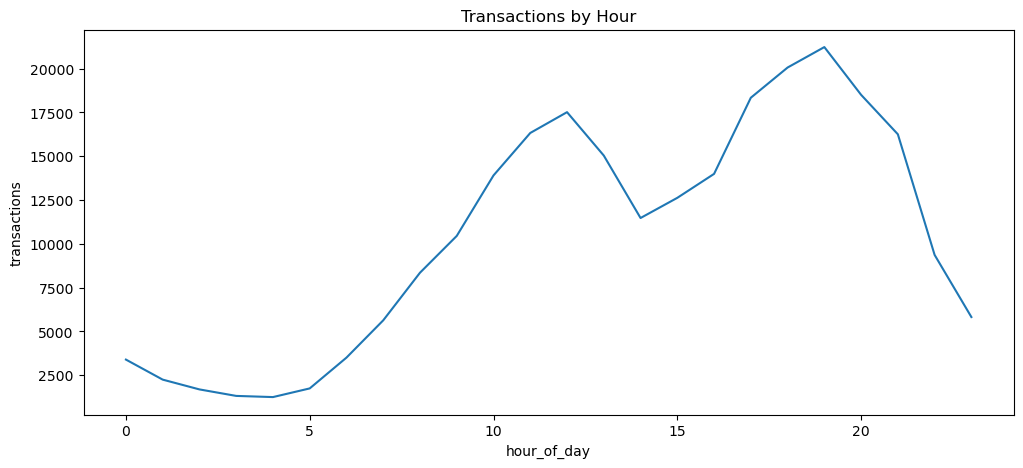

In [15]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_transactions,
    x="hour_of_day",
    y="transactions"
)

plt.title("Transactions by Hour")
plt.show()

In [16]:
#Daily Analysis
daily_transactions = (
    df.groupby("day_of_week")
      .size()
      .reset_index(name="transactions")
)

daily_transactions

,day_of_week,transactions
0,Friday,35496
1,Monday,36495
2,Saturday,35334
3,Sunday,36003
4,Thursday,35432
5,Tuesday,35540
6,Wednesday,35700


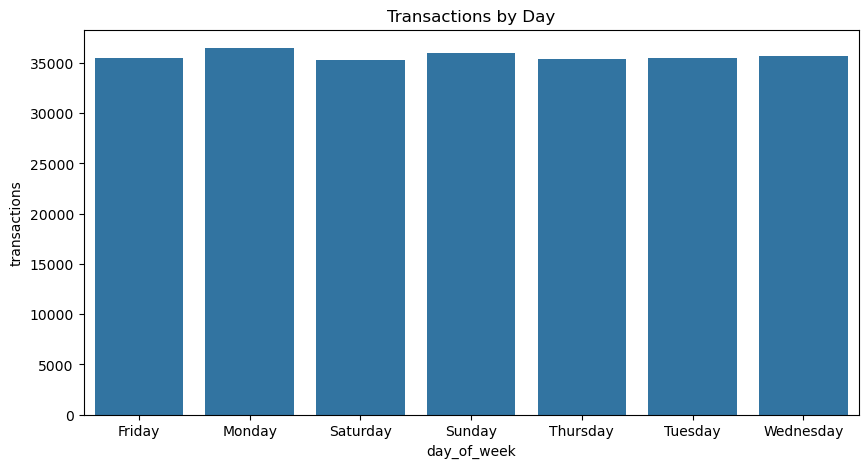

In [17]:
#Daily Trend Chart
plt.figure(figsize=(10,5))

sns.barplot(
    data=daily_transactions,
    x="day_of_week",
    y="transactions"
)

plt.title("Transactions by Day")
plt.show()

In [18]:
weekend_analysis = (
    df.groupby("is_weekend")
      .size()
      .reset_index(name="transactions")
)

weekend_analysis

,is_weekend,transactions
0,0,178663
1,1,71337


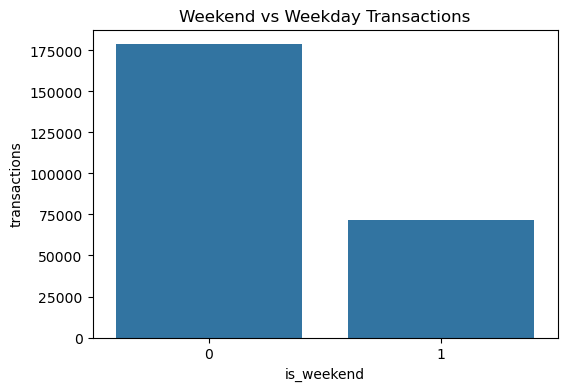

In [19]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=weekend_analysis,
    x="is_weekend",
    y="transactions"
)

plt.title("Weekend vs Weekday Transactions")
plt.show()

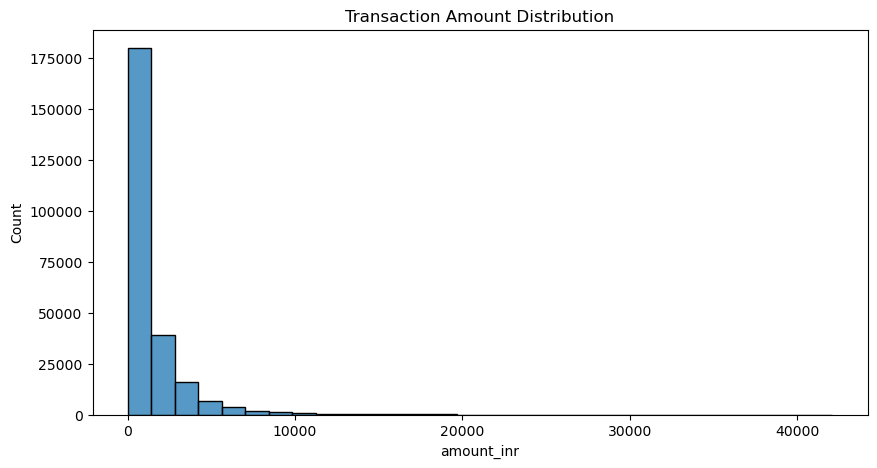

In [20]:
#Transaction Amount Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df["amount_inr"],
    bins=30
)

plt.title("Transaction Amount Distribution")
plt.show()

In [21]:
#Monthly Trend
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["year_month"] = (
    df["timestamp"]
      .dt.to_period("M")
      .astype(str)
)
monthly_trend = (
    df.groupby("year_month")
      .size()
      .reset_index(name="transactions")
)

monthly_trend


,year_month,transactions
0,2024-01,21221
1,2024-02,19759
2,2024-03,21234
3,2024-04,20536
4,2024-05,21333
5,2024-06,20628
6,2024-07,21207
7,2024-08,21231
8,2024-09,20597
9,2024-10,21252


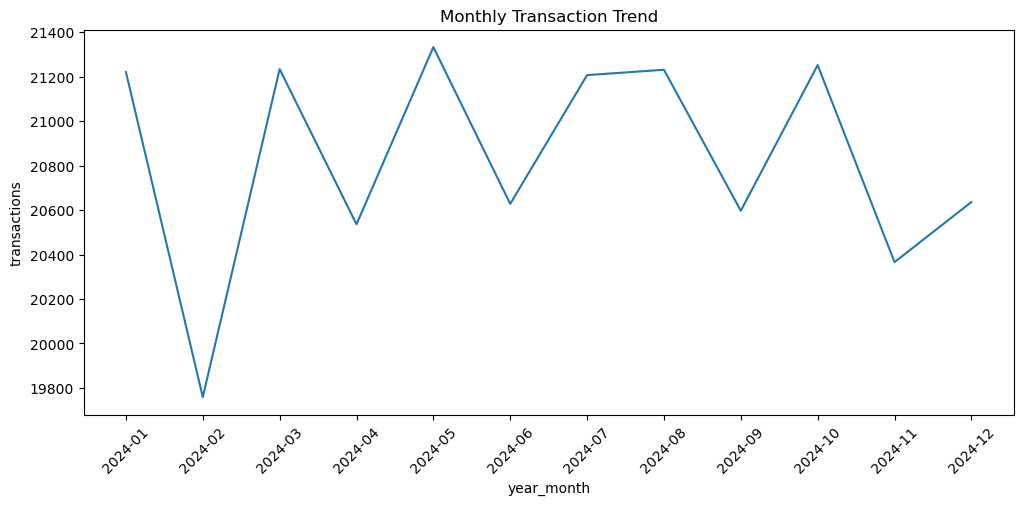

In [22]:
#Monthly Chart
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_trend,
    x="year_month",
    y="transactions"
)

plt.xticks(rotation=45)
plt.title("Monthly Transaction Trend")
plt.show()

In [23]:
transaction_summary = pd.DataFrame({
    "Metric":[
        "Total Transactions",
        "Total Volume",
        "Average Amount",
        "Success Rate",
        "Failure Rate"
    ],
    "Value":[
        total_transactions,
        total_volume,
        avg_amount,
        success_rate,
        failure_rate
    ]
})

In [24]:
transaction_summary.to_csv(
    "../dataset/transaction_summary.csv",
    index=False
)
hourly_transactions.to_csv(
    "../dataset/hourly_transactions.csv",
    index=False
)
daily_transactions.to_csv(
    "../dataset/daily_transactions.csv",
    index=False
)